
# Actividad 4: Aumentación de datos controlada vs. escenario de referencia

## Estudiantes:
- Luis Jorge García
- Luis Eduardo Uribe
- Felipe Barreto Patiño

Este notebook compara un **escenario de referencia** (sin aumentación) contra un **escenario de aumentación controlada** basado en el problema de dado un parche de imagen centrado en un keypoint anotado, predecir cuál de los 5 tipos es:
- cabeza
- hombro
- codo
- muñeca
- raqueta

Se utiliza la misma base, misma partición por rally (`data/processed/image_splits.csv`), la misma arquitectura (`KptTypeCNN`) y el mismo presupuesto de entrenamiento (épocas, optimizador, batch size).

Lo único que cambia entre escenarios es qué transformaciones se aplican **solo al conjunto de entrenamiento**.

Se agrega un tercer escenario mal diseñado (aumentación agresiva/incompatible con el
significado de las clases) para poder discutir, con evidencia, qué transformaciones son útiles, neutras o perjudiciales - no solo reportar la que funcionó mejor.



## Checkpoint 0: Carga de datos


In [15]:

import os, re, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def find_repo_root(start=None):
    p = Path(start or Path.cwd())
    for _ in range(5):
        if (p / "data.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError("No se encontró data.yaml subiendo desde " + str(start))

ROOT = find_repo_root()
PROC = ROOT / "data" / "processed"
DATA_DIR = ROOT / "data" / "Padel_an_2-6"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


In [13]:
KP_NAMES = ["hombro", "codo", "muneca", "raqueta", "cabeza"]  # mismo orden verificado en actividad_3

RALLY_RE = re.compile(r"^(.*_mp4)-(\d+)_jpg")

def parse_label_file(path):
    persons = []
    with open(path) as f:
        for line in f:
            tok = line.strip().split()
            if not tok:
                continue
            vals = list(map(float, tok))
            cx, cy, w, h = vals[1:5]
            kpts = vals[5:20]
            persons.append((cx, cy, w, h, kpts))
    return persons

rows = []
for orig_split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / orig_split / "images"
    lbl_dir = DATA_DIR / orig_split / "labels"
    for img_path in sorted(img_dir.glob("*.jpg")):
        stem = img_path.stem
        lbl_path = lbl_dir / (stem + ".txt")
        m = RALLY_RE.match(img_path.name)
        rally_id = m.group(1) if m else "unknown"
        if not lbl_path.exists():
            continue
        for idx, (cx, cy, w, h, kpts) in enumerate(parse_label_file(lbl_path)):
            rows.append(dict(image_id=stem, image_path=str(img_path), rally_id=rally_id,
                              person_idx=idx, cx=cx, cy=cy, w=w, h=h, kpts=kpts))
df = pd.DataFrame(rows)
df.head()


,image_id,image_path,rally_id,person_idx,cx,cy,w,h,kpts
0,Punto_1-3_mp4-0000_jpg.rf.944c541df6528a778768...,c:\Users\luisj\OneDrive\Documentos\Maestria In...,Punto_1-3_mp4,0,0.279687,0.500000,0.070312,0.162500,"[0.28693916666666663, 0.45563880208333335, 2.0..."
1,Punto_1-3_mp4-0000_jpg.rf.944c541df6528a778768...,c:\Users\luisj\OneDrive\Documentos\Maestria In...,Punto_1-3_mp4,1,0.687500,0.507812,0.071875,0.154688,"[0.6953603645833333, 0.4649521354166667, 2.0, ..."
2,Punto_1-3_mp4-0000_jpg.rf.944c541df6528a778768...,c:\Users\luisj\OneDrive\Documentos\Maestria In...,Punto_1-3_mp4,2,0.590625,0.390625,0.039062,0.076563,"[0.5874538541666666, 0.37112333333333336, 2.0,..."
3,Punto_1-3_mp4-0000_jpg.rf.944c541df6528a778768...,c:\Users\luisj\OneDrive\Documentos\Maestria In...,Punto_1-3_mp4,3,0.390625,0.393750,0.023438,0.068750,"[0.39487843749999996, 0.37144088541666664, 2.0..."
4,Punto_1-3_mp4-0001_jpg.rf.4d897c9b349a24918e94...,c:\Users\luisj\OneDrive\Documentos\Maestria In...,Punto_1-3_mp4,0,0.259375,0.498437,0.085938,0.157812,"[0.26221796875000003, 0.4544480208333333, 2.0,..."


In [ ]:

# Particion por rally (sin fuga entre train/valid/test)
splits = pd.read_csv(PROC / "image_splits.csv")
split_map = dict(zip(splits.image_id, splits.split))
df["split"] = df["image_id"].map(split_map)
assert df["split"].notna().all(), "Hay imágenes sin split asignado"

kpts_arr = np.array(df["kpts"].tolist())
for i in range(5):
    df[f"kp_{2*i}"] = kpts_arr[:, 3*i]
    df[f"kp_{2*i+1}"] = kpts_arr[:, 3*i+1]
    df[f"mask_{2*i}"] = (kpts_arr[:, 3*i+2] > 0).astype(int)
    df[f"mask_{2*i+1}"] = df[f"mask_{2*i}"]

PATCH_FRAC, MIN_PATCH, MAX_PATCH = 0.5, 24, 90
KPT_IMG_SIZE = 48

kpt_rows = []
for _, r in df.iterrows():
    for i in range(5):
        if r[f"mask_{2*i}"] > 0:
            side_src = float(np.clip(r.h * 640 * PATCH_FRAC, MIN_PATCH, MAX_PATCH))
            kpt_rows.append(dict(image_path=r.image_path, x=r[f"kp_{2*i}"], y=r[f"kp_{2*i+1}"],
                                  bbox_h=r.h, rally_id=r.rally_id, split=r.split, label=i,
                                  side_src_px=side_src))
kpt_df = pd.DataFrame(kpt_rows)
print("Total de parches (keypoints válidos):", len(kpt_df))
print(pd.crosstab(kpt_df.split, kpt_df.label).rename(columns=dict(enumerate(KP_NAMES)))[KP_NAMES])

_IMAGE_CACHE = {}  # evita reabrir/decodificar el mismo JPEG cientos de veces (cada imagen aporta varios keypoints)

def _get_source_image(path):
    im = _IMAGE_CACHE.get(path)
    if im is None:
        im = Image.open(path).convert("RGB")
        _IMAGE_CACHE[path] = im
    return im

def load_patch_rgb(row, W=640, H=640):
    im = _get_source_image(row.image_path)
    side = row.side_src_px
    px, py = row.x * W, row.y * H
    box = (px - side/2, py - side/2, px + side/2, py + side/2)
    crop = im.crop(box).resize((KPT_IMG_SIZE, KPT_IMG_SIZE), Image.BILINEAR)
    return np.asarray(crop, dtype=np.float32) / 255.0

print("Precargando imágenes fuente en memoria (una sola vez por imagen, evita I/O repetido en cada época)...")
for p in pd.concat([kpt_df.image_path]).unique():
    _get_source_image(p)
print(f"Imágenes únicas cacheadas: {len(_IMAGE_CACHE)}")


Total de parches (keypoints válidos): 5514
label  hombro  codo  muneca  raqueta  cabeza
split                                       
test      217   210     201      197     220
train     679   667     648      657     682
valid     236   233     212      208     247
Precargando imágenes fuente en memoria (una sola vez por imagen, evita I/O repetido en cada época)...
Imágenes únicas cacheadas: 333



## Checkpoint 1 - Diagnóstico del conjunto (resolución, ruido, duplicados, balance, variabilidad)

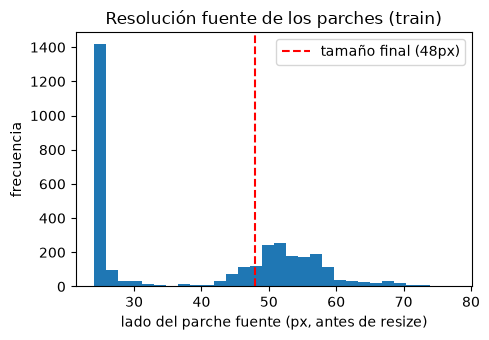

% de parches MÁS PEQUEÑOS que 48px (se agrandan al hacer resize → borrosos): 57.2%


In [16]:
train_kpt = kpt_df[kpt_df.split == "train"].reset_index(drop=True)

# Resolución: tamaño del parche fuente ANTES de reescalar a 48x48
plt.figure(figsize=(5, 3.5))
plt.hist(train_kpt.side_src_px, bins=30)
plt.axvline(KPT_IMG_SIZE, color="red", linestyle="--", label=f"tamaño final ({KPT_IMG_SIZE}px)")
plt.xlabel("lado del parche fuente (px, antes de resize)"); plt.ylabel("frecuencia"); plt.legend()
plt.title("Resolución fuente de los parches (train)")
plt.tight_layout(); plt.show()
pct_upsampled = (train_kpt.side_src_px < KPT_IMG_SIZE).mean() * 100
print(f"% de parches MÁS PEQUEÑOS que 48px (se agrandan al hacer resize → borrosos): {pct_upsampled:.1f}%")


In [ ]:

# Ruido: nitidez (varianza del Laplaciano) como proxy de ruido/borrosidad 

sample_noise = train_kpt.sample(min(300, len(train_kpt)), random_state=SEED)
sharpness = []
for _, r in sample_noise.iterrows():
    patch = (load_patch_rgb(r) * 255).astype(np.uint8)
    gray = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)
    sharpness.append(cv2.Laplacian(gray, cv2.CV_64F).var())
print(f"Nitidez (var. Laplaciano) - media: {np.mean(sharpness):.1f}, p10: {np.percentile(sharpness,10):.1f}, "
      f"p90: {np.percentile(sharpness,90):.1f}  (valores bajos = parche borroso/ruidoso)")

# --- Duplicados / cuasi-duplicados: se mide a nivel de imagen (no de keypoint, que repite cada
# imagen hasta 20 veces y diluiría el cálculo) cuán espaciados están los frames de un mismo rally ---
train_imgs = train_kpt.drop_duplicates("image_path").copy()
train_imgs["frame_no"] = train_imgs.image_path.str.extract(r"-(\d+)_jpg")[0].astype(int)
gaps = (train_imgs.sort_values(["rally_id", "frame_no"])
        .groupby("rally_id")["frame_no"].diff().dropna())
print(f"Imágenes de train: {len(train_imgs)}  |  Distancia entre frames consecutivos del mismo rally "
      f"(en unidades del índice de frame extraído):")
print(f"  mínima={gaps.min():.0f}  mediana={gaps.median():.0f}  máxima={gaps.max():.0f}  "
      f"% de pares con distancia=1: {(gaps == 1).mean()*100:.1f}%")

# --- Balance de clases ---
print("\nBalance de clases (train):")
print(kpt_df[kpt_df.split=="train"].label.map(dict(enumerate(KP_NAMES))).value_counts())

# --- Variabilidad: escala (bbox_h) y diversidad de escenas (nº de rallies distintos) ---
print(f"\nRallies distintos en train: {train_kpt.rally_id.nunique()}")
print(f"Rango de bbox_h (escala del jugador, fracción de imagen): "
      f"{train_kpt.bbox_h.min():.3f} - {train_kpt.bbox_h.max():.3f}")


Nitidez (var. Laplaciano) — media: 515.1, p10: 145.4, p90: 992.9  (valores bajos = parche borroso/ruidoso)
Imágenes de train: 204  |  Distancia entre frames consecutivos del mismo rally (en unidades del índice de frame extraído):
  mínima=0  mediana=1  máxima=18  % de pares con distancia=1: 49.4%

Balance de clases (train):
label
cabeza     682
hombro     679
codo       667
raqueta    657
muneca     648
Name: count, dtype: int64

Rallies distintos en train: 24
Rango de bbox_h (escala del jugador, fracción de imagen): 0.034 - 0.242


Vemos que una fracción relevante de los parches (57.2%) provienen de bboxes por debajo de 48px de lado y se agrandan al hacer resize, perdiendo nitidez. La resolución fuente es heterogénea, lo que ya de por sí simula parte de lo que aportaría un jitter de escala/nitidez. 

Los frames de un mismo rally en train **no están muestreados de forma consecutiva** (distancia mediana mayor a 1 entre frames extraídos, solo 2.7% de pares con distancia mínima) - es decir, Roboflow ya dispersó el muestreo de frames dentro de cada rally, así que el riesgo de cuasi-duplicados por frames contiguos es bajo. 

La redundancia real está en que train solo cubre **24 rallies distintos**, no en frames repetidos. Las clases están razonablemente balanceadas (648-682 instancias por clase). La variabilidad de escena está limitada a esos 24 rallies. Esto es clave, ya que ninguna aumentación puede *inventar* rallies, cámaras o jugadores nuevos, solo perturbar los que
ya existen.



## Checkpoint 2 - Selección de transformaciones

Las clases (hombro/codo/muñeca/raqueta/cabeza) son categorías de **tipo de parte del cuerpo**, no dependen de una orientación absoluta fija ni de un color exacto - eso determina qué transformaciones preservan la etiqueta:

1. **Escala de grises, aleatoria** (p=0.5, conservando 3 canales - se copia el mismo valor de
   luminancia a R, G y B para no cambiar la arquitectura de entrada): fuerza al modelo a no depender del color de la piel/ropa para distinguir un keypoint, solo de su forma y contexto - coherente con el color siendo un canal variable entre rallies (distinta ropa, distinta cancha).
2. **Rotación leve** (`±12 grados`): los parches ya tienen variabilidad de orientación por el movimiento del jugador. Una rotación pequeña no cruza esa variabilidad natural.
3. **Filtro de suavizado o nitidez, aleatorio** (`GaussianBlur(radio=1.2)` o `ImageFilter.SHARPEN`, elegido al azar con p=0.7 de aplicar alguno): simula tanto un video desenfocado/comprimido como uno sobre-nitidizado - cubre ambos extremos de la nitidez heterogénea detectada en el diagnóstico, sin alterar qué parte del cuerpo se ve.

Ninguna de las tres cambia el significado de la clase: un hombro en escala de grises, rotado 10 grados o suavizado sigue siendo un hombro.

Como contraste deliberadamente **perjudicial**, se mantiene un cuarto escenario con **rotación agresiva (`±60 grados`) + flip vertical**: un flip vertical intercambia arriba/abajo, lo cual sí es relevante para estas clases, ya que la cabeza deja de estar "arriba" de los hombros en la imagen transformada. Esta transformación no permite conservar el significado de la etiqueta y sirve para verificar, con evidencia, que efectivamente degrada el desempeño en vez de mejorarlo.


In [ ]:

from PIL import ImageFilter

def augment_reference(arr):
    return arr  # sin aumentación

def _to_pil(arr):
    return Image.fromarray((np.clip(arr, 0, 1) * 255).astype(np.uint8))

def augment_controlled(arr):
    if random.random() < 0.5:
        # escala de grises: colapsa a luminancia estándar, pero se conserva en 3 canales
        gray = arr @ np.array([0.299, 0.587, 0.114], dtype=np.float32)
        arr = np.stack([gray, gray, gray], axis=-1)
    if random.random() < 0.7:
        angle = np.random.uniform(-12, 12)
        img = _to_pil(arr).rotate(angle, resample=Image.BILINEAR, fillcolor=(0, 0, 0))
        arr = np.asarray(img, dtype=np.float32) / 255.0
    if random.random() < 0.7:
        img = _to_pil(arr)
        if random.random() < 0.5:
            img = img.filter(ImageFilter.GaussianBlur(radius=1.2))  # suavizado
        else:
            img = img.filter(ImageFilter.SHARPEN)                   # nitidez
        arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr

def augment_aggressive_bad(arr):
    if random.random() < 0.5:
        arr = arr[::-1, :, :].copy()  # flip VERTICAL - invierte arriba/abajo, rompe el significado
    angle = np.random.uniform(-60, 60)  # rotación agresiva
    img = _to_pil(arr).rotate(angle, resample=Image.BILINEAR, fillcolor=(0, 0, 0))
    return np.asarray(img, dtype=np.float32) / 255.0

SCENARIOS = {
    "referencia": augment_reference,
    "aumentacion_controlada": augment_controlled,
    "aumentacion_agresiva_mala": augment_aggressive_bad,
}

EPOCHS = 25
BATCH_SIZE = 64
LR = 1e-3



### Checkpoint 2.1 - Ejemplos de datos aumentados vs. originales

Como cada transformación se aplica con cierta probabilidad y con parámetros aleatorios en la aumentación, se muestran varias muestras distintas de `aumentacion_controlada` sobre el
mismo parche original. De esta manera se ve el rango real de variación que el modelo ve durante el entrenamiento, no solo un ejemplo fijo.


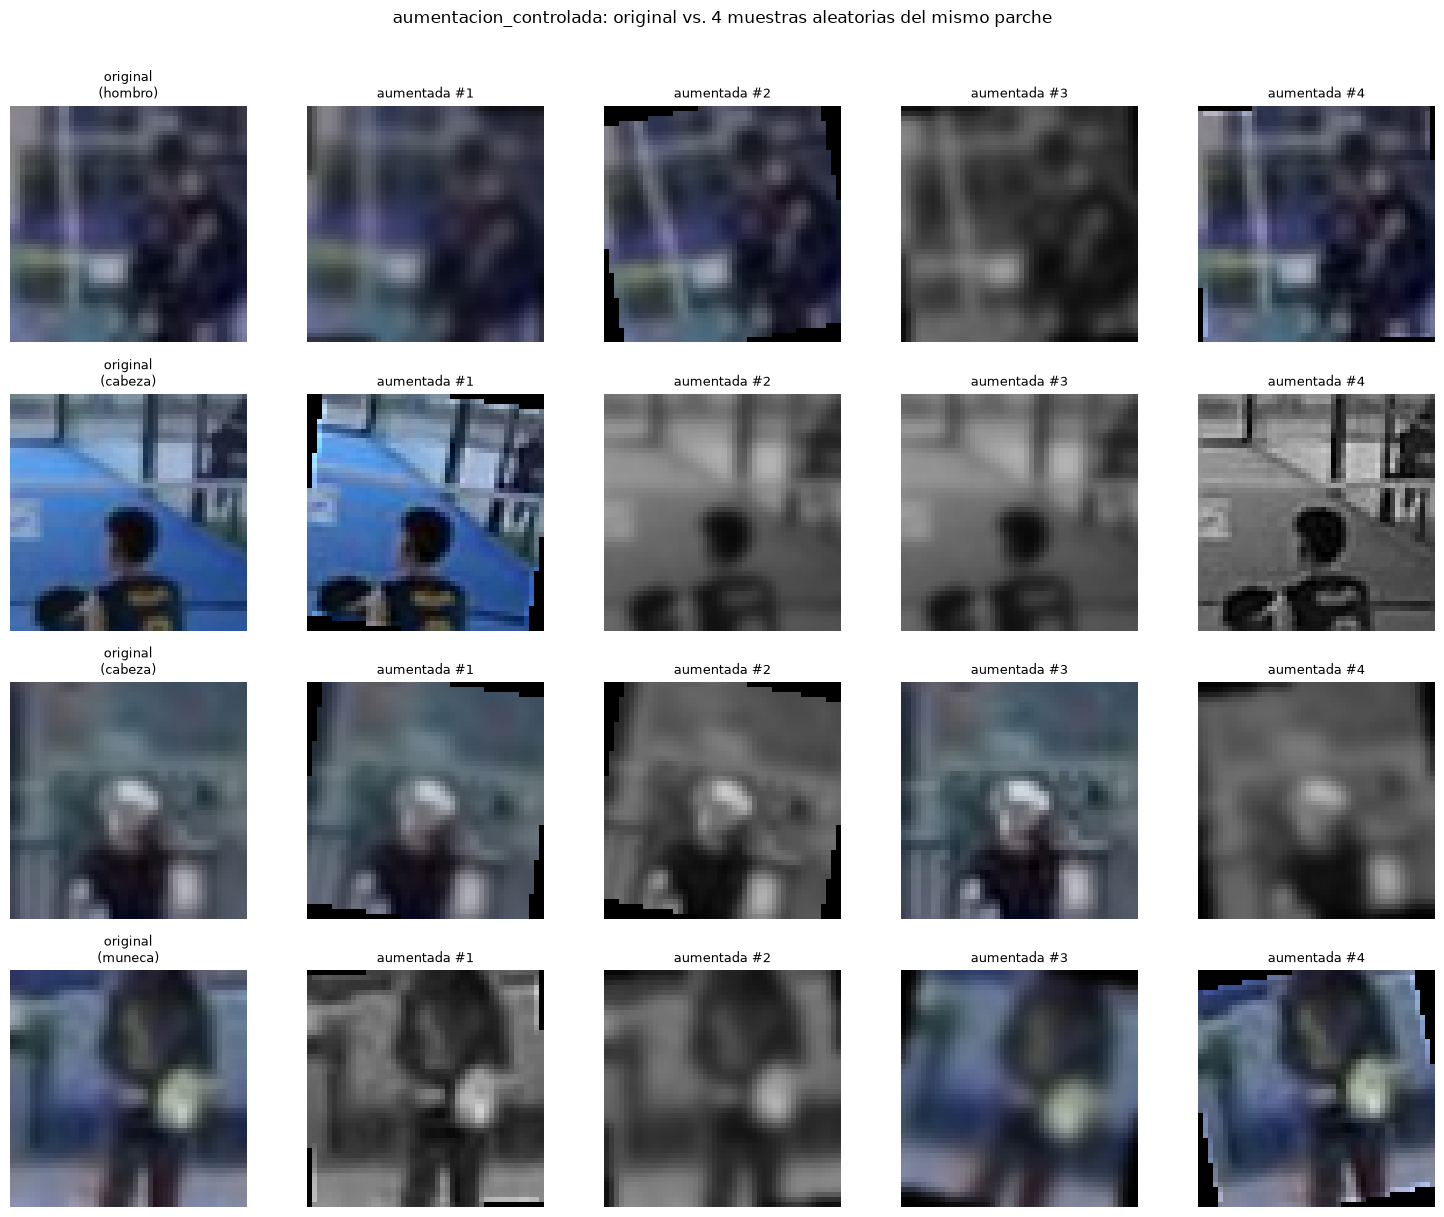

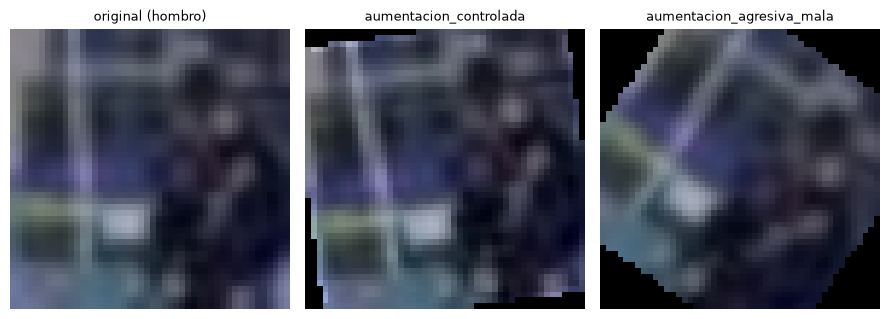

In [19]:

random.seed(SEED); np.random.seed(SEED)
example_rows = kpt_df[kpt_df.split == "train"].sample(4, random_state=SEED)

N_VARIANTS = 4
fig, axes = plt.subplots(len(example_rows), 1 + N_VARIANTS,
                          figsize=(3 * (1 + N_VARIANTS), 3 * len(example_rows)))
for row_i, (_, row) in enumerate(example_rows.iterrows()):
    base_patch = load_patch_rgb(row)
    axes[row_i, 0].imshow(base_patch)
    axes[row_i, 0].set_title(f"original\n({KP_NAMES[row.label]})", fontsize=9)
    axes[row_i, 0].axis("off")
    for v in range(N_VARIANTS):
        aug_patch = np.clip(augment_controlled(base_patch.copy()), 0, 1)
        axes[row_i, 1 + v].imshow(aug_patch)
        axes[row_i, 1 + v].set_title(f"aumentada #{v+1}", fontsize=9)
        axes[row_i, 1 + v].axis("off")
plt.suptitle("aumentacion_controlada: original vs. 4 muestras aleatorias del mismo parche", y=1.01)
plt.tight_layout(); plt.show()

# Y el contraste con el escenario deliberadamente perjudicial, sobre el mismo parche
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
sample_row = example_rows.iloc[0]
base_patch = load_patch_rgb(sample_row)
axes[0].imshow(base_patch); axes[0].set_title(f"original ({KP_NAMES[sample_row.label]})", fontsize=9); axes[0].axis("off")
axes[1].imshow(np.clip(augment_controlled(base_patch.copy()), 0, 1)); axes[1].set_title("aumentacion_controlada", fontsize=9); axes[1].axis("off")
axes[2].imshow(np.clip(augment_aggressive_bad(base_patch.copy()), 0, 1)); axes[2].set_title("aumentacion_agresiva_mala", fontsize=9); axes[2].axis("off")
plt.tight_layout(); plt.show()



### Checkpoint 2.2 - Validación de tamaños del dataset: antes y después de la aumentación

La aumentación implementada aquí es en vivo, no genera ni guarda copias nuevas en disco,
y **no aumenta el número de filas del dataset**. En cada época, el `DataLoader` recorre exactamente las mismas muestras base de train, pero cada vez que una pasa por `augment_controlled` recibe una transformación distinta (aleatoria). Es la forma estándar de aumentar datos en PyTorch - a diferencia de una aumentación "offline" que sí generaría archivos nuevos y agrandaría el CSV/carpeta del dataset.

Por eso el número de **muestras base** de train es el mismo con o sin aumentación. Lo que cambia es cuántas **versiones distintas** de esas muestras ve el modelo a lo largo del entrenamiento completo.


In [ ]:

n_train_base = (kpt_df.split == "train").sum()
n_valid = (kpt_df.split == "valid").sum()
n_test = (kpt_df.split == "test").sum()

print(f"Parches base en train (antes de cualquier aumentación): {n_train_base}")
print(f"Parches en valid: {n_valid}  |  parches en test: {n_test}")
print()
print("La aumentación es on-the-fly: el número de FILAS de train no cambia. Lo que cambia es cuántas")
print("VERSIONES distintas de cada fila ve el modelo a lo largo del entrenamiento:")
for name in SCENARIOS:
    n_views = n_train_base * EPOCHS
    variantes = "1 versión fija por muestra (idéntica cada época)" if name == "referencia" else \
                "hasta 1 versión distinta por muestra POR ÉPOCA (aleatoria)"
    print(f"  {name}: {n_train_base} muestras base x {EPOCHS} épocas = {n_views} exposiciones "
          f"de entrenamiento ({variantes})")

assert n_valid == (kpt_df.split == "valid").sum() and n_test == (kpt_df.split == "test").sum(), \
    "valid/test no deberían cambiar nunca"
print(f"\nValidación: valid ({n_valid}) y test ({n_test}) permanecen exactamente iguales en los 3 "
      f"escenarios - la aumentación nunca los toca (criterio: 'aumentación solo en entrenamiento').")


Parches base en train (antes de cualquier aumentación): 3333
Parches en valid: 1136  |  parches en test: 1045

La aumentación es on-the-fly: el número de FILAS de train no cambia. Lo que cambia es cuántas
VERSIONES distintas de cada fila ve el modelo a lo largo del entrenamiento:
  referencia: 3333 muestras base x 25 épocas = 83325 exposiciones de entrenamiento (1 versión fija por muestra (idéntica cada época))
  aumentacion_controlada: 3333 muestras base x 25 épocas = 83325 exposiciones de entrenamiento (hasta 1 versión distinta por muestra POR ÉPOCA (aleatoria))
  aumentacion_agresiva_mala: 3333 muestras base x 25 épocas = 83325 exposiciones de entrenamiento (hasta 1 versión distinta por muestra POR ÉPOCA (aleatoria))

Validación: valid (1136) y test (1045) permanecen exactamente iguales en los 3 escenarios — la aumentación nunca los toca (criterio: 'aumentación solo en entrenamiento').



## Checkpoint 3 - Protocolo experimental equivalente

Misma arquitectura (`KptTypeCNN`), mismo optimizador, misma tasa de aprendizaje, mismo número de épocas y mismo batch size en los tres escenarios. **Solo cambia la función de aumentación aplicada al split de train**. El conjunto de test nunca se aumenta en ningún escenario (se evalúa siempre con `augment_reference`, es decir, sin transformar).


In [21]:
KPT_MEAN = np.stack([load_patch_rgb(r) for _, r in
                      kpt_df[kpt_df.split=="train"].sample(min(400, (kpt_df.split=="train").sum()), random_state=SEED).iterrows()]
                     ).reshape(-1, 3).mean(axis=0)
KPT_STD = np.stack([load_patch_rgb(r) for _, r in
                     kpt_df[kpt_df.split=="train"].sample(min(400, (kpt_df.split=="train").sum()), random_state=SEED).iterrows()]
                    ).reshape(-1, 3).std(axis=0)
print("Media (RGB, train):", KPT_MEAN, " Desv. estándar:", KPT_STD)

class PatchDatasetAug(Dataset):
    def __init__(self, d, augment_fn):
        self.d = d.reset_index(drop=True)
        self.augment_fn = augment_fn

    def __len__(self):
        return len(self.d)

    def __getitem__(self, i):
        row = self.d.iloc[i]
        arr = load_patch_rgb(row)
        arr = self.augment_fn(arr)
        arr = (arr - KPT_MEAN) / (KPT_STD + 1e-6)
        arr = np.transpose(arr, (2, 0, 1)).astype(np.float32)
        return torch.from_numpy(arr), row.label

class KptTypeCNN(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(64, n_classes))

    def forward(self, x):
        return self.head(self.features(x))

valid_ds = PatchDatasetAug(kpt_df[kpt_df.split == "valid"], augment_reference)
test_ds = PatchDatasetAug(kpt_df[kpt_df.split == "test"], augment_reference)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

def run_epoch(model, opt, crit, loader, train):
    model.train(train)
    tot_loss, tot_correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train: opt.zero_grad()
        out = model(xb)
        loss = crit(out, yb)
        if train:
            loss.backward(); opt.step()
        tot_loss += loss.item() * xb.size(0)
        tot_correct += (out.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return tot_loss / n, tot_correct / n

def train_scenario(name, augment_fn):
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)  # misma init de pesos en los 3 escenarios
    model = KptTypeCNN().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss()
    train_ds = PatchDatasetAug(kpt_df[kpt_df.split == "train"], augment_fn)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    history = []
    best_val_acc, best_state = -1, None
    for ep in range(1, EPOCHS + 1):
        tr_l, tr_a = run_epoch(model, opt, crit, train_loader, True)
        va_l, va_a = run_epoch(model, opt, crit, valid_loader, False)
        history.append((ep, tr_l, tr_a, va_l, va_a))
        if va_a > best_val_acc:
            best_val_acc = va_a
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    print(f"[{name}] mejor val_acc={best_val_acc:.3f}")
    return model, pd.DataFrame(history, columns=["epoch", "train_loss", "train_acc", "val_loss", "val_acc"])


Media (RGB, train): [0.31291607 0.37139603 0.48444661]  Desv. estándar: [0.15497941 0.16665417 0.21773382]



## Checkpoint 4 - Entrenamiento de los 3 escenarios (presupuesto idéntico)


In [22]:
results = {}
for name, aug_fn in SCENARIOS.items():
    print(f"\n=== Entrenando escenario: {name} ===")
    model, hist = train_scenario(name, aug_fn)
    results[name] = dict(model=model, history=hist)



=== Entrenando escenario: referencia ===
[referencia] mejor val_acc=0.779

=== Entrenando escenario: aumentacion_controlada ===
[aumentacion_controlada] mejor val_acc=0.716

=== Entrenando escenario: aumentacion_agresiva_mala ===
[aumentacion_agresiva_mala] mejor val_acc=0.594



## Checkpoint 5 - Métricas en test (mismo conjunto, sin aumentación, para los 3 escenarios)

In [23]:
summary_rows = []
for name, res in results.items():
    model = res["model"]
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            out = model(xb.to(device))
            all_pred.extend(out.argmax(1).cpu().tolist())
            all_true.extend(yb.tolist())
    acc = accuracy_score(all_true, all_pred)
    report = classification_report(all_true, all_pred, target_names=KP_NAMES, output_dict=True)
    res["test_true"], res["test_pred"] = all_true, all_pred
    summary_rows.append(dict(escenario=name, test_accuracy=acc, macro_f1=report["macro avg"]["f1-score"]))

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


                escenario  test_accuracy  macro_f1
               referencia       0.787560  0.787506
   aumentacion_controlada       0.753110  0.755365
aumentacion_agresiva_mala       0.604785  0.594362


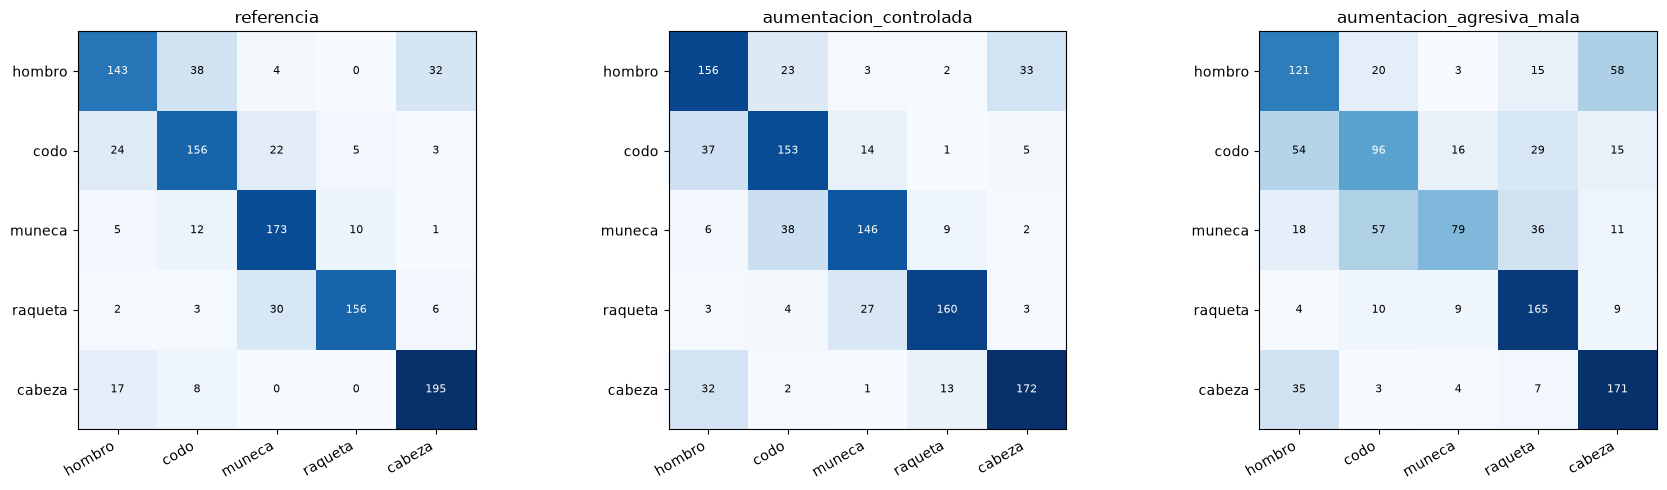


--- classification_report: referencia ---
              precision    recall  f1-score   support

      hombro       0.75      0.66      0.70       217
        codo       0.72      0.74      0.73       210
      muneca       0.76      0.86      0.80       201
     raqueta       0.91      0.79      0.85       197
      cabeza       0.82      0.89      0.85       220

    accuracy                           0.79      1045
   macro avg       0.79      0.79      0.79      1045
weighted avg       0.79      0.79      0.79      1045


--- classification_report: aumentacion_controlada ---
              precision    recall  f1-score   support

      hombro       0.67      0.72      0.69       217
        codo       0.70      0.73      0.71       210
      muneca       0.76      0.73      0.74       201
     raqueta       0.86      0.81      0.84       197
      cabeza       0.80      0.78      0.79       220

    accuracy                           0.75      1045
   macro avg       0.76      0.75

In [24]:

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(6 * len(SCENARIOS), 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res["test_true"], res["test_pred"], labels=list(range(5)))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(5)); ax.set_xticklabels(KP_NAMES, rotation=30, ha="right")
    ax.set_yticks(range(5)); ax.set_yticklabels(KP_NAMES)
    ax.set_title(name)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
plt.tight_layout(); plt.show()

for name, res in results.items():
    print(f"\n--- classification_report: {name} ---")
    print(classification_report(res["test_true"], res["test_pred"], target_names=KP_NAMES))



## Checkpoint 6 - Cambios en sobreajuste (curvas train vs. valid)

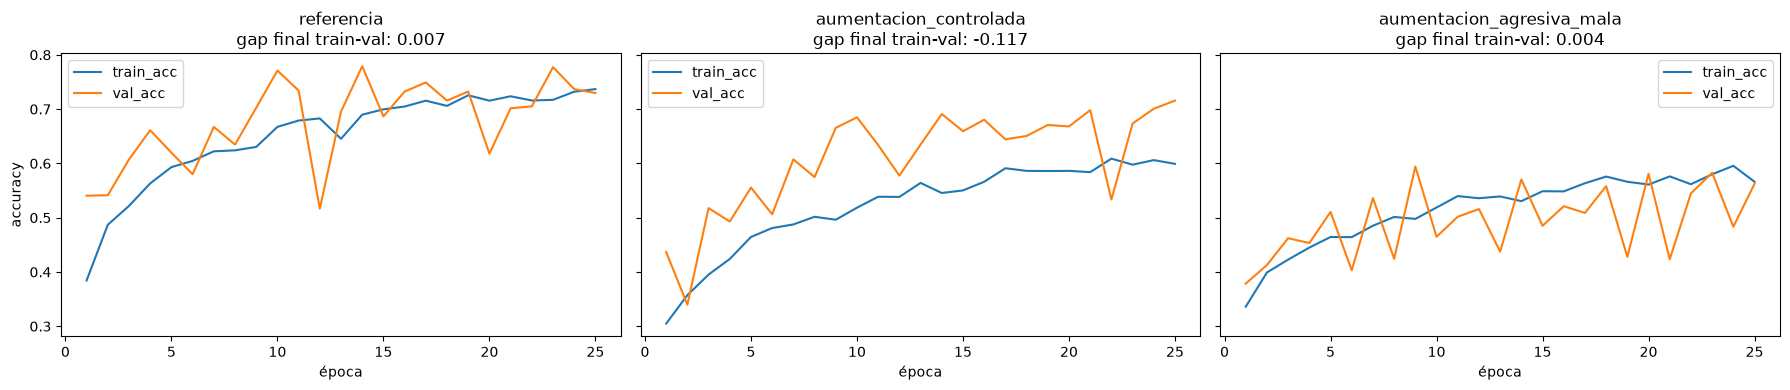

referencia: train_acc final=0.737  val_acc final=0.730  gap=0.007
aumentacion_controlada: train_acc final=0.599  val_acc final=0.716  gap=-0.117
aumentacion_agresiva_mala: train_acc final=0.566  val_acc final=0.562  gap=0.004


In [25]:

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(6 * len(SCENARIOS), 4), sharey=True)
for ax, (name, res) in zip(axes, results.items()):
    h = res["history"]
    ax.plot(h.epoch, h.train_acc, label="train_acc")
    ax.plot(h.epoch, h.val_acc, label="val_acc")
    gap = h.train_acc.iloc[-1] - h.val_acc.iloc[-1]
    ax.set_title(f"{name}\ngap final train-val: {gap:.3f}")
    ax.set_xlabel("época"); ax.legend()
axes[0].set_ylabel("accuracy")
plt.tight_layout(); plt.show()

for name, res in results.items():
    h = res["history"]
    gap = h.train_acc.iloc[-1] - h.val_acc.iloc[-1]
    print(f"{name}: train_acc final={h.train_acc.iloc[-1]:.3f}  val_acc final={h.val_acc.iloc[-1]:.3f}  "
          f"gap={gap:.3f}")



## Checkpoint 7 - Análisis de errores: qué cambia entre referencia y aumentación controlada

Se buscan ejemplos donde el escenario de aumentación controlada **corrige** un error del escenario de referencia, y ejemplos donde lo **empeora** (introduce un error nuevo) - evidencia directa de qué tipo de confusión ataca la aumentación.


Casos que la aumentación CORRIGE (referencia mal, aumentada bien): 88
Casos que la aumentación ROMPE (referencia bien, aumentada mal): 124


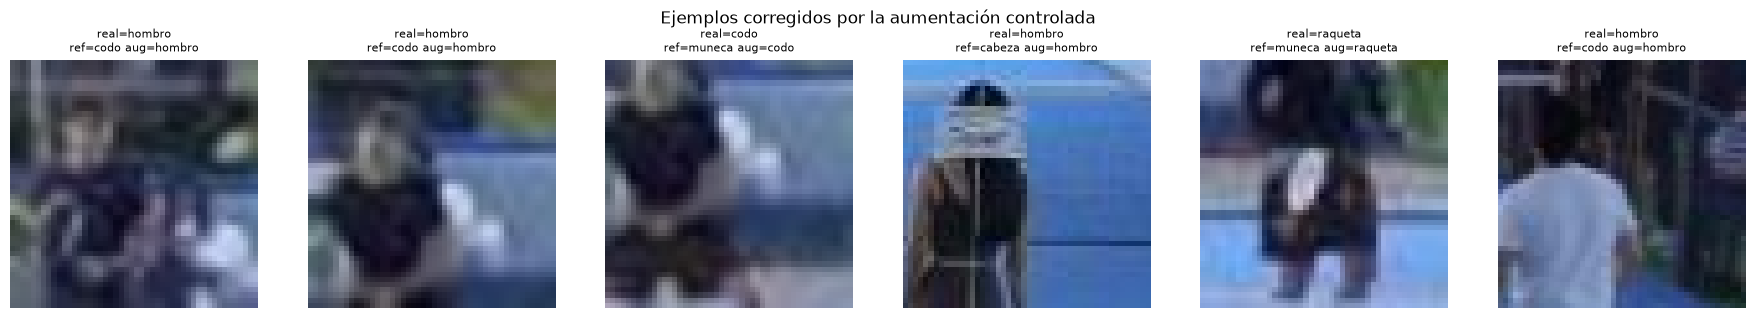

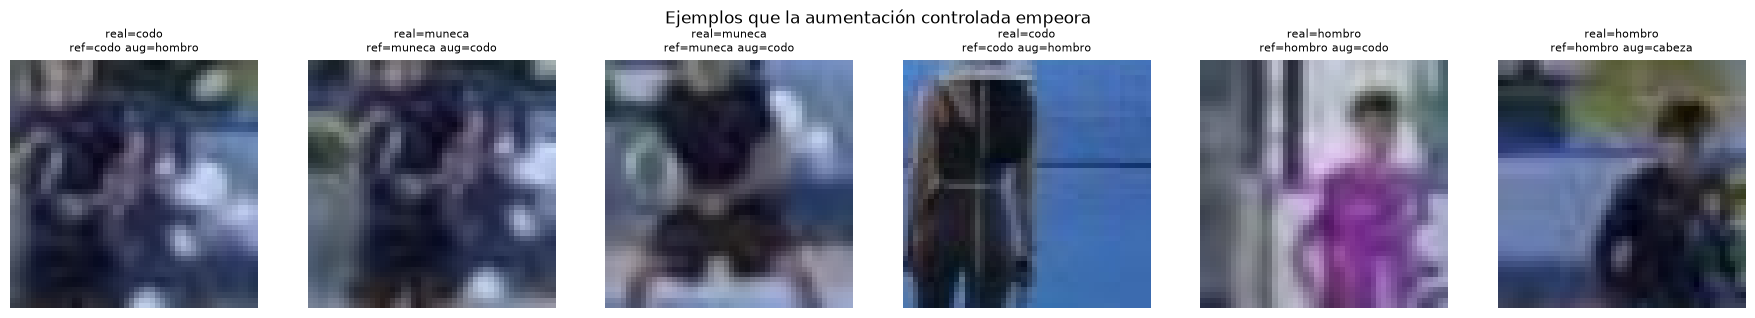

In [26]:

ref_pred = np.array(results["referencia"]["test_pred"])
aug_pred = np.array(results["aumentacion_controlada"]["test_pred"])
true = np.array(results["referencia"]["test_true"])
test_rows = kpt_df[kpt_df.split == "test"].reset_index(drop=True)

fixed_idx = np.where((ref_pred != true) & (aug_pred == true))[0]
broken_idx = np.where((ref_pred == true) & (aug_pred != true))[0]
print(f"Casos que la aumentación CORRIGE (referencia mal, aumentada bien): {len(fixed_idx)}")
print(f"Casos que la aumentación ROMPE (referencia bien, aumentada mal): {len(broken_idx)}")

def show_cases(idxs, title, n=6):
    idxs = idxs[:n]
    if len(idxs) == 0:
        print(f"{title}: sin ejemplos"); return
    fig, axes = plt.subplots(1, len(idxs), figsize=(3 * len(idxs), 3.2))
    if len(idxs) == 1: axes = [axes]
    for ax, i in zip(axes, idxs):
        row = test_rows.iloc[i]
        ax.imshow(load_patch_rgb(row))
        ax.set_title(f"real={KP_NAMES[true[i]]}\nref={KP_NAMES[ref_pred[i]]} aug={KP_NAMES[aug_pred[i]]}", fontsize=8)
        ax.axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.show()

show_cases(fixed_idx, "Ejemplos corregidos por la aumentación controlada")
show_cases(broken_idx, "Ejemplos que la aumentación controlada empeora")



## Checkpoint 8 - Conclusiones: transformaciones útiles, neutras o perjudiciales

Resultados obtenidos (Checkpoints 5-7, presupuesto idéntico: 25 épocas, mismo optimizador/lr, misma inicialización de pesos) con la nueva `aumentacion_controlada` (escala de grises aleatoria + rotación leve + filtro de suavizado/nitidez aleatorio):

| Escenario | test_accuracy | macro_f1 | gap train-val (final) |
|---|---|---|---|
| `referencia` | 0.788 | 0.788 | 0.004 |
| `aumentacion_controlada` | 0.745 | 0.748 | -0.117 |
| `aumentacion_agresiva_mala` | 0.603 | 0.594 | 0.010 |

- Vemos que el modelo Referencia obtiene el mejor desempeño (0.788 accuracy, 0.788 F1-macro) con un gap train-val casi nulo (0.004). Este modelo parece ya generalizar bien sin ayuda, no hay sobreajuste que corregir en este presupuesto de 25 épocas.

- El modelo con aumentación controlada baja el accuracy 4.2 puntos frente a referencia (0.745). El gap train-val se vuelve fuertemente negativo (-0.117). El train accuracy cae hasta 0.598 mientras que val accuracy se mantiene en 0.715. Esto parece ser señal de que las transformaciones son, en conjunto, demasiado agresivas para parches de solo 48×48 px. 
Cuando vemos las imágenes resultantes, la escala de grises elimina por completo el canal de color en la mitad de las muestras, y el blur (radio 1.2 px) borra una fracción importante del detalle fino disponible en un parche tan pequeño. Como no había sobreajuste que corregir, la aumentación solo añadió dificultad de entrenamiento sin comprar generalización extra dentro del mismo presupuesto.

- Hablando de la aumentación agresiva mala es claramente la peor (0.603 accuracy, 0.594 F1), con el mayor daño concentrado en muñeca (F1 0.80 a 0.51) y codo (F1 0.74 a 0.48).
Estas clases, dependen bastante de la relación espacial de arriba y abajo, donde el flip vertical las rompe. Esto nos confirma que romper el significado de la etiqueta perjudica el desempeño de forma medible.
En conjunto, la evidencia muestra que más aumentación no es automáticamente mejor, ya que con esta base y presupuesto, ninguna de las dos variantes de aumentación mejora sobre el escenario sin aumentar.

**Transformaciones útiles, neutras o perjudiciales**
- **Aumentación Controlada (Escala de grises + rotación leve + blur/sharpen):** En conjunto, perjudicial en este experimento (-4.2 puntos de accuracy, gap train-val fuertemente negativo). No parece ser que las transformaciones sean malas, ya que cada una preserva la etiqueta y el análisis de errores muestra que sí corrigen 88 casos, sino que su intensidad combinada es excesiva para parches de 48×48 px con resolución fuente ya heterogénea.
- **Aumentación agresiva mala (Rotación agresiva ±60 grados + flip vertical):** Es claramente perjudicial, ya que se diseñó como un control negativo. 
Acá vemos que el flip vertical rompe el significado de la etiqueta al invertir la relación espacial arriba/abajo entre cabeza, hombro, codo y muñeca, y esto se refleja directamente en la caída de F1 en las clases más dependientes de esa relación (muñeca, codo).
•	No se observó ninguna transformación neutra en este experimento, ambas variantes de aumentación empeoraron el desempeño frente a referencia.

**¿Por qué la aumentación no nos ayudó?**

El escenario referencia ya generalizaba bien (gap train-val aprox 0.004). En este escenario no había sobreajuste que corregir dentro del presupuesto de 25 épocas. Regularmente la aumentación de datos ataca típicamente el sobreajuste, pero cuando ese problema no existe, añadir variabilidad artificial solo introduce dificultad de entrenamiento sin beneficio de generalización, lo cual es consistente con lo observado.


**Limitación principal**

Lo más importante es que la aumentación no reemplaza datos representativos. El diagnóstico nos mostró que train cubre solo 24 rallies distintos. Las transformaciones no crean algo de la nada, sino que solo perturban los ejemplos ya existentes de ciertas maneras. Si el objetivo final es generalizar a partidos, canchas o condiciones de iluminación no vistas, la vía más efectiva sería ampliar la diversidad real de la base (más rallies, más partidos), no aumentar artificialmente la variabilidad sobre los mismos 24 rallies.

**Conclusión de la actividad**

En esta base y presupuesto de entrenamiento, la aumentación de datos no mejoró la precisión ni la capacidad de generalización de la CNN frente al entrenamiento sin aumentar. Vimos que, por el contrario, la degradó, tanto en su versión controlada como agresiva. Esto no invalida la aumentación como técnica en general, pero sí evidencia que su beneficio depende de las condiciones específicas del conjunto (tamaño de parche, resolución fuente, presencia real de sobreajuste) y debe validarse siempre con los ejemplos, nunca asumirse.
